# ResNet-18

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
DATA_DIR = "../data"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

assert os.path.exists(IMAGENETTE_PATH), f"Imagenette not found at {IMAGENETTE_PATH}"
print("Imagenette found, reusing existing download.")

Imagenette found, reusing existing download.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [4]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion),
            )

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

In [5]:
block_same = BasicBlock(64, 64, stride=1).to(device)
test_input = torch.randn(2, 64, 56, 56).to(device)
print(f"No downsample: {test_input.shape} -> {block_same(test_input).shape}")

block_downsample = BasicBlock(64, 128, stride=2).to(device)
print(f"With downsample: {test_input.shape} -> {block_downsample(test_input).shape}")

No downsample: torch.Size([2, 64, 56, 56]) -> torch.Size([2, 64, 56, 56])
With downsample: torch.Size([2, 64, 56, 56]) -> torch.Size([2, 128, 28, 28])


In [6]:
class ResNet18(nn.Module):

    layers_per_stage = [2, 2, 2, 2]
    stage_channels = [64, 128, 256, 512]

    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.stage1 = self._make_stage(64, self.layers_per_stage[0], stride=1)
        self.stage2 = self._make_stage(128, self.layers_per_stage[1], stride=2)
        self.stage3 = self._make_stage(256, self.layers_per_stage[2], stride=2)
        self.stage4 = self._make_stage(512, self.layers_per_stage[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

        self._initialize_weights()

    def _make_stage(self, out_channels, num_blocks, stride):

        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, stride=s))
            self.in_channels = out_channels * BasicBlock.expansion
        return nn.Sequential(*layers)

    def _initialize_weights(self):

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        return self.fc(x)

model = ResNet18(num_classes=10).to(device)
print(model)

ResNet18(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (stage1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=Tr

In [7]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [64, 10]

Output shape: torch.Size([64, 10])


In [8]:
def count_conv_params(in_ch, out_ch, kernel_size):
    return kernel_size * kernel_size * in_ch * out_ch

def count_bn_params(num_features):
    return 2 * num_features

conv1 = count_conv_params(64, 64, 3)
bn1 = count_bn_params(64)
conv2 = count_conv_params(64, 64, 3)
bn2 = count_bn_params(64)

block_manual = conv1 + bn1 + conv2 + bn2
block_torch = sum(p.numel() for p in model.stage1[0].parameters())

print(f"conv1: {conv1:,}")
print(f"bn1: {bn1:,}")
print(f"conv2: {conv2:,}")
print(f"bn2: {bn2:,}")
print(f"BasicBlock manual total: {block_manual:,}")
print(f"BasicBlock torch total:  {block_torch:,}")
assert block_manual == block_torch, "Mismatch in BasicBlock parameter count"

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal model parameters: {total_params:,}")

conv1: 36,864
bn1: 128
conv2: 36,864
bn2: 128
BasicBlock manual total: 73,984
BasicBlock torch total:  73,984

Total model parameters: 11,181,642


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [11]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=1.7000 train_acc=0.4204 | val_loss=1.4903 val_acc=0.5050 | time=68.0s
Epoch 2/10 | train_loss=1.3270 train_acc=0.5589 | val_loss=1.3976 val_acc=0.5465 | time=65.6s
Epoch 3/10 | train_loss=1.2092 train_acc=0.6066 | val_loss=1.1016 val_acc=0.6492 | time=65.8s
Epoch 4/10 | train_loss=1.1072 train_acc=0.6380 | val_loss=1.1751 val_acc=0.6069 | time=65.8s
Epoch 5/10 | train_loss=1.0243 train_acc=0.6682 | val_loss=1.0412 val_acc=0.6535 | time=66.1s
Epoch 6/10 | train_loss=0.9872 train_acc=0.6810 | val_loss=0.8231 val_acc=0.7284 | time=66.1s
Epoch 7/10 | train_loss=0.9226 train_acc=0.7014 | val_loss=0.9526 val_acc=0.6948 | time=65.9s
Epoch 8/10 | train_loss=0.9103 train_acc=0.7035 | val_loss=0.8688 val_acc=0.7225 | time=65.8s
Epoch 9/10 | train_loss=0.8440 train_acc=0.7274 | val_loss=0.7331 val_acc=0.7631 | time=65.9s
Epoch 10/10 | train_loss=0.8266 train_acc=0.7330 | val_loss=0.7907 val_acc=0.7488 | time=66.0s


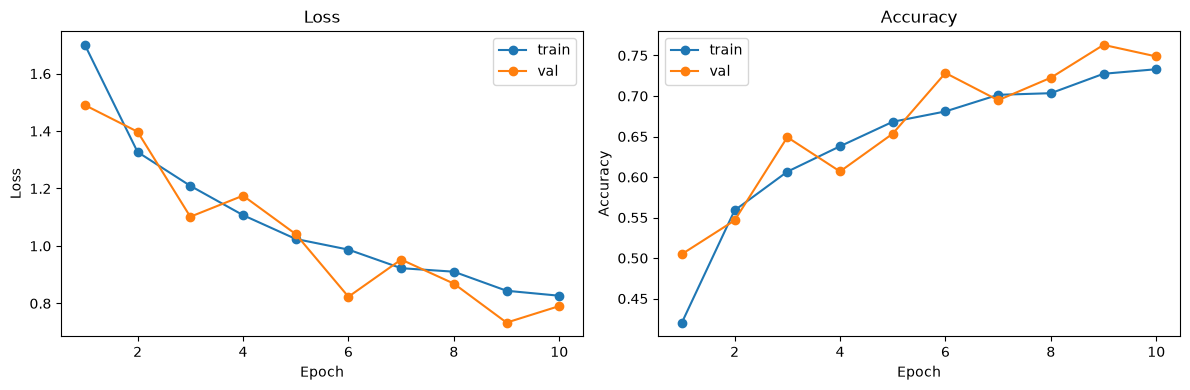

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

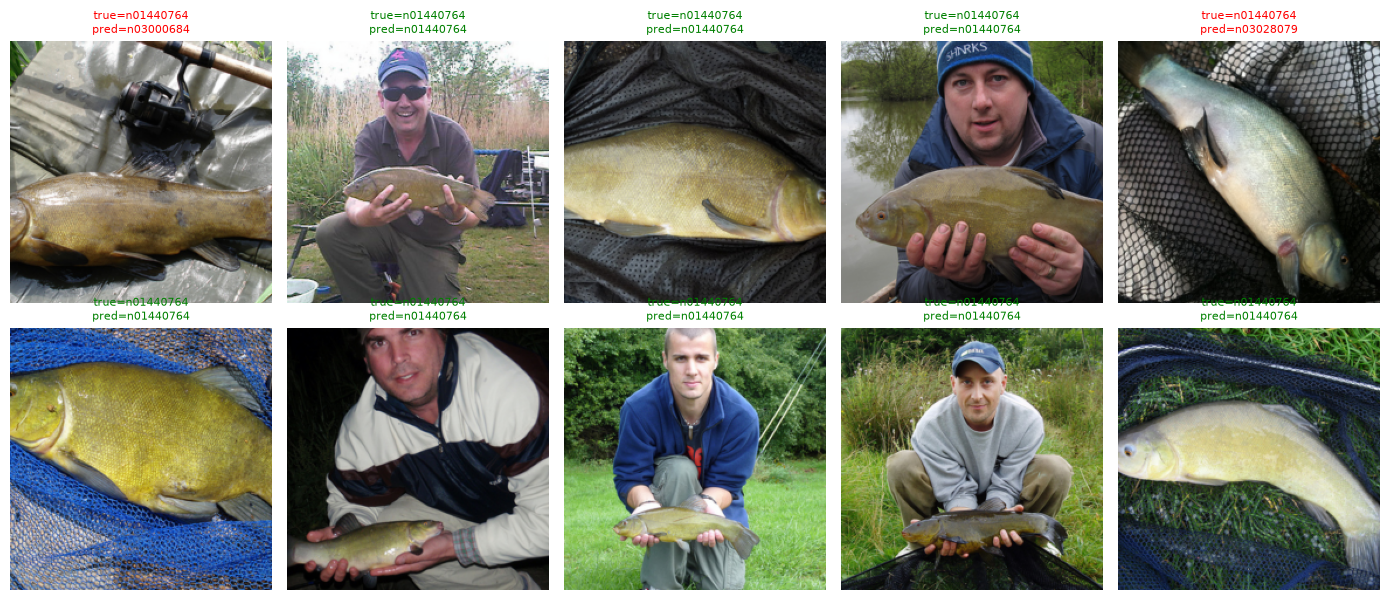

In [13]:
model.eval()
sample_images, sample_labels = next(iter(val_loader))
class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: see output above. Notably
smaller than VGG (~11M vs ~138-144M) despite similar depth to VGG16,
because ResNet-18 also has no large fully connected layers (just one
Linear(512, num_classes) after global average pooling).

**Why no plateau (unlike VGG19).**
BatchNorm + Kaiming init, part of the original architecture, should prevent
the vanishing gradient plateau seen with VGG19

**Why Adam instead of SGD with momentum.** The original paper used SGD with
momentum=0.9, weight decay 0.0001, and a step learning rate schedule. We
used Adam for simpler, more reliable convergence without manual tuning.

**Why 10 output classes instead of 1000.** Imagenette is a 10-class subset
of ImageNet, so the final FC layer was sized accordingly instead of the
original 1000-way classifier. All other architectural parameters (input
size 224x224, BasicBlock configuration, stem layers, skip connections) are
kept identical to the original paper.